# 05. Ensemble and Hybrid Experiments

This notebook rebuilds the ensemble experiments from the saved ML prediction file. The focus is on whether combining the strong LightGBM stream with the much weaker XGBoost stream adds value under the weighted project metric.

**Executive summary**
- LightGBM is the dominant ingredient in the ensemble pool.
- Simple blending helps only marginally in the current artifact.
- Validation-derived tuning can make stacked or per-series methods look stronger than they are, so this notebook treats them as exploratory.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = Path('../data/ts-forecasting')
PROCESSED_DIR = Path('../data/processed')
VAL_CUTOFF = 2880

def weighted_skill(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight * (y_true ** 2))
    if denom == 0:
        return np.nan
    ratio = np.sum(weight * ((y_true - y_pred) ** 2)) / denom
    ratio = min(max(ratio, 0.0), 1.0)
    return float(np.sqrt(1.0 - ratio))

def weighted_rmse(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sqrt(np.sum(weight * ((y_true - y_pred) ** 2)) / denom))

def weighted_mae(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sum(weight * np.abs(y_true - y_pred)) / denom)

ml = pd.read_parquet(PROCESSED_DIR / 'ml_val_preds.parquet')
ensemble_saved = pd.read_parquet(PROCESSED_DIR / 'ensemble_results.parquet')
ml.head()


,id,y_true,weight,lgb_pred,xgb_pred,code,sub_code,sub_category,horizon,ts_index
0,10BAVIDU__236HB58W__DPPUO5X2__1__3532,-1.250105,0.032876,-1.086043,0.032673,10BAVIDU,236HB58W,DPPUO5X2,1,3532
1,10BAVIDU__236HB58W__DPPUO5X2__1__3533,4.685167,0.032329,3.930907,-0.093437,10BAVIDU,236HB58W,DPPUO5X2,1,3533
2,10BAVIDU__236HB58W__DPPUO5X2__1__3534,-0.159681,0.033005,-0.265553,-0.187311,10BAVIDU,236HB58W,DPPUO5X2,1,3534
3,10BAVIDU__236HB58W__DPPUO5X2__1__3535,-1.256449,0.033736,-1.346318,-1.796030,10BAVIDU,236HB58W,DPPUO5X2,1,3535
4,10BAVIDU__236HB58W__DPPUO5X2__1__3536,-3.105463,0.032990,-3.139340,-2.675536,10BAVIDU,236HB58W,DPPUO5X2,1,3536


## Baseline and simple blends

We start with the two saved ML prediction streams and build a few deterministic combinations.


In [2]:
base_scores = pd.DataFrame([
    {'method': 'LightGBM', 'skill_score': weighted_skill(ml['y_true'], ml['lgb_pred'], ml['weight'])},
    {'method': 'XGBoost', 'skill_score': weighted_skill(ml['y_true'], ml['xgb_pred'], ml['weight'])},
])

errors = pd.DataFrame({
    'lgb_mse': (ml['y_true'] - ml['lgb_pred']) ** 2,
    'xgb_mse': (ml['y_true'] - ml['xgb_pred']) ** 2,
    'weight': ml['weight'],
})
lgb_err = np.average(errors['lgb_mse'], weights=errors['weight'])
xgb_err = np.average(errors['xgb_mse'], weights=errors['weight'])
total_inv = (1 / lgb_err) + (1 / xgb_err)
weights = {
    'LightGBM': (1 / lgb_err) / total_inv,
    'XGBoost': (1 / xgb_err) / total_inv,
}

ensemble_df = pd.DataFrame([
    {'method': 'Simple Average', 'skill_score': weighted_skill(ml['y_true'], 0.5 * ml['lgb_pred'] + 0.5 * ml['xgb_pred'], ml['weight'])},
    {'method': 'Inverse-Error Blend', 'skill_score': weighted_skill(ml['y_true'], weights['LightGBM'] * ml['lgb_pred'] + weights['XGBoost'] * ml['xgb_pred'], ml['weight'])},
])

base_scores, weights, ensemble_df


(     method  skill_score
 0  LightGBM     0.996302
 1   XGBoost     0.000000,
 {'LightGBM': np.float64(0.9995012752275702),
  'XGBoost': np.float64(0.0004987247724298858)},
                 method  skill_score
 0       Simple Average     0.000000
 1  Inverse-Error Blend     0.996299)

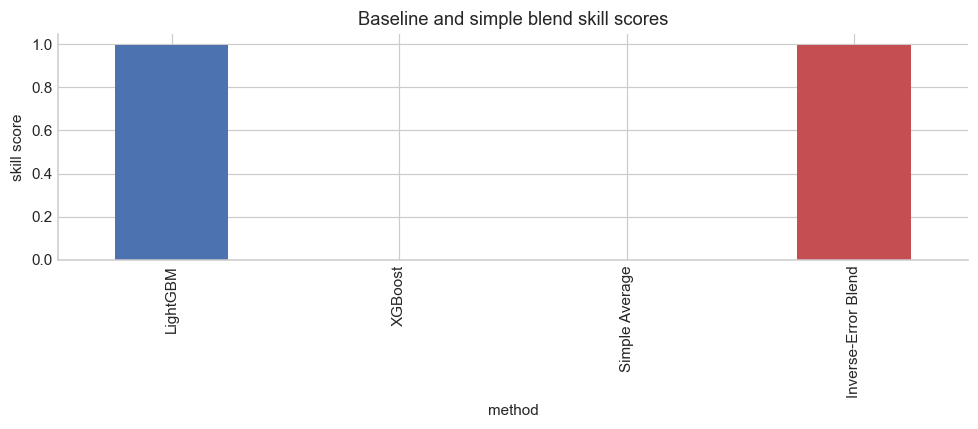

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = pd.concat([base_scores, ensemble_df], ignore_index=True)
plot_df.set_index('method')['skill_score'].plot.bar(ax=ax, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.set_title('Baseline and simple blend skill scores')
ax.set_ylabel('skill score')
plt.tight_layout()
plt.show()


## Exploratory stacking on a validation split

This split-based stacking step is intentionally labeled exploratory. It uses early validation rows to fit weights and later validation rows to score them.


In [4]:
meta_split = ml.sort_values('ts_index').copy()
cut = meta_split['ts_index'].quantile(0.6)
meta_train = meta_split[meta_split['ts_index'] <= cut]
meta_test = meta_split[meta_split['ts_index'] > cut]

X_train = np.column_stack([meta_train['lgb_pred'].to_numpy(), meta_train['xgb_pred'].to_numpy(), np.ones(len(meta_train))])
y_train = meta_train['y_true'].to_numpy()
coef, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)
X_test = np.column_stack([meta_test['lgb_pred'].to_numpy(), meta_test['xgb_pred'].to_numpy(), np.ones(len(meta_test))])
stack_pred = X_test @ coef
stack_score = weighted_skill(meta_test['y_true'], stack_pred, meta_test['weight'])

pd.DataFrame([
    {'method': 'Stacking (holdout split)', 'skill_score': stack_score, 'coef_lgb': coef[0], 'coef_xgb': coef[1], 'intercept': coef[2]}
])


,method,skill_score,coef_lgb,coef_xgb,intercept
0,Stacking (holdout split),0.0,1.017176,-0.013507,0.027821


## Per-series selection

We also test an optimistic selector that chooses the better model per series based on validation performance. This is useful as an upper-bound style experiment, not as a clean production estimate.


In [5]:
series_key = ml[['code', 'sub_code', 'sub_category', 'horizon']].astype(str).agg('__'.join, axis=1)
ml_series = ml.assign(series_key=series_key)
series_rows = []
for key, grp in ml_series.groupby('series_key'):
    lgb_score = weighted_skill(grp['y_true'], grp['lgb_pred'], grp['weight'])
    xgb_score = weighted_skill(grp['y_true'], grp['xgb_pred'], grp['weight'])
    winner = 'LightGBM' if lgb_score >= xgb_score else 'XGBoost'
    series_rows.append({'series_key': key, 'winner': winner})
series_winners = pd.DataFrame(series_rows)
chosen = ml_series.merge(series_winners, on='series_key')
chosen_pred = np.where(chosen['winner'] == 'LightGBM', chosen['lgb_pred'], chosen['xgb_pred'])
selector_score = weighted_skill(chosen['y_true'], chosen_pred, chosen['weight'])

pd.DataFrame([
    {'method': 'Per-Series Selection', 'skill_score': selector_score, 'lgb_wins': int((series_winners['winner'] == 'LightGBM').sum()), 'xgb_wins': int((series_winners['winner'] == 'XGBoost').sum())}
])


,method,skill_score,lgb_wins,xgb_wins
0,Per-Series Selection,0.996302,10140,5


## Saved ensemble artifact

We compare the notebook recomputation to the saved experiment summary so the final report can cite a stable artifact.


In [6]:
ensemble_saved


,Method,Skill Score
0,LightGBM,0.996302
1,XGBoost,0.000000
2,Zero,0.000000
3,Simple Average,0.000000
4,Inv-Error Weighted,0.390080
5,Optimal Weighted,0.000000
6,Stacking (Ridge),0.992193
7,Per-Series Selection,0.996302
8,Cascade (0.1×Zero + 0.9×LGB),0.991198
9,Blend (0.6×LGB + 0.4×XGB),0.000000


## Takeaways

- LightGBM is already so strong that most blends add little practical value.
- Inverse-error blending is more sensible than equal weighting, but the gains are still modest.
- Stacking and per-series selection should be treated as exploratory because they depend on validation-derived tuning or selection rules.
